# **Predicting Presence of Glaucoma using Retinal Fundus Images of both Eyes of a Patient and their Clinical Data through Deep Learning**

Glaucoma is a leading cause of blindness and vision impairment worldwide, with an estimated 64.3 million people aged between 40 and 80, affected in 2013 and this number expected to increase to 111.8 million by 2040 [1]. Retinal fundus images, which are photographs of the back of the eye, have long been used in the diagnosis and management of glaucoma [7]. These images provide important information about the health of the optic nerve and the presence of other ocular conditions such as diabetic retinopathy and age-related macular degeneration [7]. In recent years, there has been growing interest in using machine learning algorithms, including deep learning, to automatically detect glaucoma from fundus images [6]. 

**//TODO write this following part up properly when i have done it in lit review.**

There are two key steps in the detection of Glaucoma from such images:
1. Optic disc segmentation
2. 

*Talk about what algs ppl have used, and talk about the way they do not consider both eyes.*


The proposed PAPILA dataset [10] consists of 244 patient records from the Hospital General Universitario Reina Sofía, in Spain, between 2018 and 2020, each providing structured information about clinical data and images of the optic disc and optic cup of both eyes of the same patient. The records were properly anonymized and a unique identifier was assigned to each record. Each record contains:
1.	Age and gender of the patient.
2.	RFI (Retinal Fundus Images) of both eyes, taken using a Topcon TRC-NW400 non-mydriatic retinal camera, with 8 bits per color channel and a resolution of 2576 × 1934 pixels.
3.	Diagnostic labeling of the patient, categorized as glaucomatous, non-glaucomatous, or suspect, based on a comprehensive evaluation of the patient's clinical data.
4.	Manual segmentations of the optic disc (OD) and optic cup (OC) in the RFI of both eyes, annotated by two expert ophthalmologists using a developed tool with image review, zoom, and contour editing capabilities.
5.	Clinical data and medical test results, including refractive error, presence or absence of the crystalline lens, Intraocular Pressure (IOP) of both eyes, corneal thickness, axial length, and Mean Defect (MD) of both eyes, measured using various diagnostic tools and techniques. The MD value is used to measure visual field loss in glaucomatous patients.

**Our goal is to contrast whether using both images of eyes can give better accuracy in the diagnosis of whether a single eye in question is glaucomous or not.**

The following is a summary of the tasks that we will be performing:

- Load the dataset
- Understand the data, the attributes and their correlations
- Split the data into training and test set
- Apply normalisation, scaling and other transformations to the attributes if needed
- Build a machine learning model
- Evaluate the model and investigate the errors
- Tune model to improve performance

First, let's import a few common modules:

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from PIL import Image
import utils

ROOT_DIR = 'PAPILA Dataset/'

Now let us load our dataset. Key things to note: Dataset contains records for 34 suspect cases for each eye. We neglect these, as we want to perform a binary classification.
TODO LATER

## Read diagnostic labels

Returns three arrays of size 488: diagnosis label, eye ID and patient ID.
(it is actually less than 488 as i removed the suspect values from the actual spreadsheet)

In [2]:
y, eyeID, patID = utils.get_diagnosis(ROOT_DIR)

In [3]:
y.size  # this returns 420. Which is the total number of eyes we will consider.

420

In [59]:
# works as intended. Righteye, left eye, righteye, left eye, etc.
for i in range (50):
    print(y[i])

1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


## Read clinical data:

Returns a pandas Data Frame with the clinical data.

In [39]:
df_od, df_os = utils.read_clinical_data(ROOT_DIR)
df_os

ID,Age,Gender,Diagnosis,dioptre_1,dioptre_2,astigmatism,Phakic/Pseudophakic,Pneumatic,Perkins,Pachymetry,Axial_Length,VF_MD
#004,58,1,1,1.5,-2.5,85,1,NaN,19,511,22.96,-6.77
#005,89,1,1,-0.5,-2,100,1,24,10,575,24.33,-7.44
#010,72,1,1,2.5,-1,70,0,18,NaN,600,22.34,-11.44
#013,70,1,1,2.25,-1.75,98,0,13,18,495,22.85,-7.75
#014,60,1,1,0.25,-1.5,160,0,24,17,496,24.17,-4.65
...,...,...,...,...,...,...,...,...,...,...,...,...
#289,64,0,0,0.75,-1.5,93,1,10,NaN,531,22.31,NaN
#290,75,1,0,0.25,-0.25,160,1,19,NaN,573,22.01,NaN
#291,55,0,0,1.5,-1.25,76,0,14,NaN,443,23.51,NaN
#292,56,1,0,1.25,-0.75,79,0,9,NaN,479,23.84,NaN


In [40]:
df_os.info()

<class 'pandas.core.frame.DataFrame'>
Index: 210 entries, #004 to #293
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Age                  210 non-null    object
 1   Gender               210 non-null    object
 2   Diagnosis            210 non-null    object
 3   dioptre_1            202 non-null    object
 4   dioptre_2            208 non-null    object
 5   astigmatism          208 non-null    object
 6   Phakic/Pseudophakic  205 non-null    object
 7   Pneumatic            179 non-null    object
 8   Perkins              42 non-null     object
 9   Pachymetry           206 non-null    object
 10  Axial_Length         208 non-null    object
 11  VF_MD                48 non-null     object
dtypes: object(12)
memory usage: 21.3+ KB


In [41]:
df_os["Gender"].value_counts()

1    137
0     73
Name: Gender, dtype: int64

# **ML model for classification using clinical data**

### Model 1 - Simple classification from just age:

Step 1: Splitting data into training and test sets: TODO Look at strified sampling (practical 1)

In [42]:
train_set, test_set = train_test_split(df_od, test_size=0.2, random_state=42)
print(len(train_set), "training instances +", len(test_set), "test instances")

train_set["Age"].values  #convert to numpy array


NameError: name 'train_test_split' is not defined

Step 2: Exploring the attributes TODO

Step 3: Data preperations and transformations TODO

Step 4: Linear regression algorithm:

Removing the 34 suspect cases:

In [ ]:
# This has all been done in the excel spreadsheet itself, not needed here anymore
df_od = df_od[df_od.Diagnosis != 2]
df_od

ID,Age,Gender,Diagnosis,dioptre_1,dioptre_2,astigmatism,Phakic/Pseudophakic,Pneumatic,Perkins,Pachymetry,Axial_Length,VF_MD
#004,58,1,1,1.5,-1.75,85,0,NaN,19,501,23.06,-3.26
#005,89,1,1,-0.75,-1.25,101,1,13,14,565,23.81,-14.98
#010,72,1,1,2.25,-1.5,105,0,16,NaN,590,22.46,-12.58
#013,70,1,1,3,-1,65,0,13,17,500,22.75,-14.24
#014,60,1,1,0.25,-0.5,155,0,11,14,505,23.81,-11.37
...,...,...,...,...,...,...,...,...,...,...,...,...
#289,64,0,0,0.5,-1,120,1,12,NaN,529,22.27,NaN
#290,75,1,0,0.25,-0.25,5,1,14,NaN,577,22,NaN
#291,55,0,0,1.25,-1.25,92,0,12,NaN,452,23.53,NaN
#292,56,1,0,1.75,-1.5,73,0,10,NaN,499,23.68,NaN


Formatting into numpy array, and data as ints.

In [ ]:
X, y = df_od["Age"], df_od["Diagnosis"]
X = X.values.astype('int')
y=y.values.astype('int')
X

array([58, 89, 72, 70, 60, 78, 69, 87, 87, 62, 81, 62, 61, 78, 26, 41, 34,
       29, 37, 56, 57, 34, 30, 30, 34, 29, 62, 76, 67, 78, 69, 71, 71, 77,
       65, 74, 65, 90, 60, 72, 73, 72, 68, 57, 73, 78, 56, 72, 74, 50, 78,
       78, 82, 68, 67, 74, 55, 49, 55, 71, 78, 41, 41, 63, 61, 43, 70, 76,
       74, 66, 59, 43, 61, 69, 73, 64, 70, 66, 53, 71, 81, 63, 50, 73, 62,
       46, 53, 69, 58, 47, 51, 66, 61, 43, 64, 54, 71, 67, 64, 43, 45, 63,
       62, 41, 71, 71, 55, 52, 55, 46, 76, 54, 66, 64, 63, 82, 67, 58, 73,
       64, 61, 67, 69, 81, 63, 50, 68, 79, 68, 61, 65, 50, 75, 57, 64, 50,
       39, 54, 52, 49, 70, 62, 50, 66, 56, 64, 55, 56, 68, 48, 65, 79, 52,
       79, 67, 70, 47, 50, 58, 45, 76, 47, 72, 51, 63, 59, 60, 49, 82, 65,
       56, 67, 63, 65, 69, 41, 73, 62, 47, 54, 49, 43, 57, 68, 55, 57, 69,
       56, 67, 69, 41, 61, 39, 45, 79, 59, 60, 42, 68, 73, 44, 58, 50, 64,
       65, 64, 75, 55, 56, 39])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
                             X, y, test_size=0.2, random_state=42, shuffle=True)

NameError: name 'train_test_split' is not defined

In [ ]:
X_train

NameError: name 'X_train' is not defined

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()
lr.fit(X_train.reshape(-1, 1), y_train)

# gnb.fit(X_train, y_train)
y_pred = lr.predict(X_test.reshape(-1,1))
accuracy_score(y_test, y_pred)

NameError: name 'X_train' is not defined

In [ ]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score

gnb = MultinomialNB() # or:
gnb = GaussianNB() 
gnb.fit(X_train.reshape(-1, 1), y_train)

# gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test.reshape(-1,1))
accuracy_score(y_test, y_pred)

NameError: name 'X_train' is not defined

In [ ]:
print(lr.predict([[80]]))

NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

# **DL model for classification using Retinal Fundus Images of one eye**

The following uses the segmentations given by experts that are found in the contours folder. We find an approximately central point in the optic disk and produce an 800x800 image centred around that point. This is done for all the images, which are then all stored in images.

In [4]:
imagedim = 800
imagesDir = os.listdir(ROOT_DIR + "FundusImages/")
contoursDir = os.listdir(ROOT_DIR + "ExpertsSegmentations/Contours/")
images = np.zeros((len(imagesDir), imagedim,imagedim, 3))  # array to store all the images

for i, _ in enumerate(imagesDir):
    image = np.array(Image.open(ROOT_DIR + "FundusImages/" + imagesDir[i])) # reading image
    contour = np.loadtxt(ROOT_DIR + "ExpertsSegmentations/Contours/" + contoursDir[i])  # reading contour    
    images[i] = utils.crop_image_from_contour(image, contour, imagedim)
    # images[i] = images[i] /255  # allows mapping to floats for matplotlib

Example of one of the images:

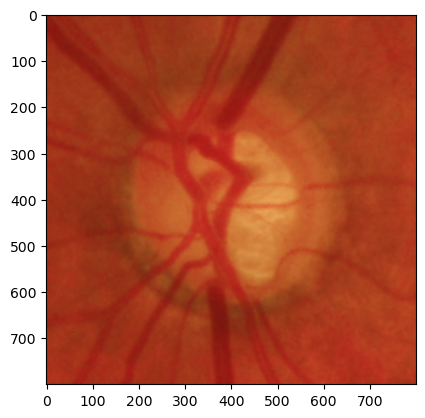

In [5]:
plt.imshow(images[1].astype(np.uint8))  # conversion here for now

Now we use pre-trained models to classify the images that we have. Lets start by using the resnet50 pretrained model. We first need to resize our images to the required size:

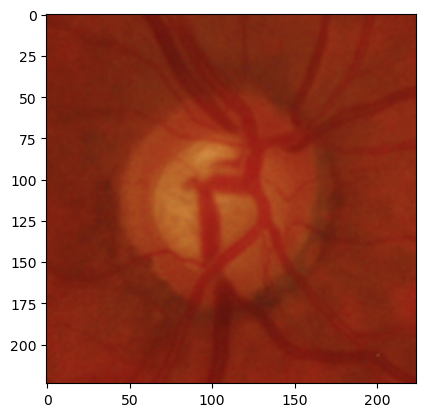

In [6]:
resizedImages = np.zeros((len(imagesDir), 224,224, 3))  # array to store all the images
for i, _ in enumerate(imagesDir):
    toImage = Image.fromarray(images[i].astype(np.uint8))
    resizedImages[i] = np.array(toImage.resize((224, 224)))

plt.imshow(resizedImages[0].astype(np.uint8))

Using a pretrained network for classification:

In [46]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load the VGG16 network
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))



In [18]:
# other pretrained networks:
from tensorflow.keras.applications.resnet50 import ResNet50
# Load the resnet network
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


94765736/94765736 [==============================] - 17s 0us/step


In [26]:
# other pretrained networks:
from tensorflow.keras.applications.xception import Xception
# Load the resnet network
base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

83683744/83683744 [==============================] - 17s 0us/step


In [47]:
# Add new output layer
x = Flatten()(base_model.output)
output_layer = Dense(2, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output_layer)

In [48]:
# Freeze the layers
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [49]:
base_model.trainable = True

# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 200

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  19


In [36]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

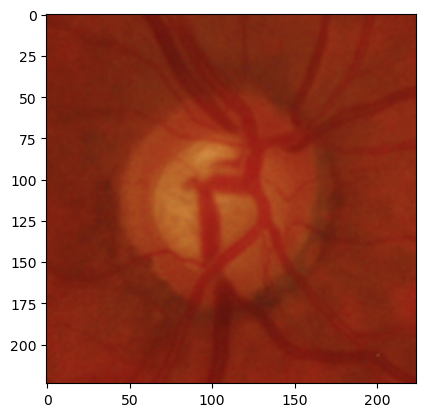

In [29]:
plt.imshow(resizedImages[0].astype(int))

In [30]:
from sklearn.model_selection import train_test_split

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(resizedImages, y, test_size=0.3, random_state=42)

# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


In [40]:
import tensorflow as tf
from tensorflow import keras

In [43]:
model = keras.models.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(2, activation='softmax')
])

In [50]:
with tf.device('/device:GPU:0'):
  model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
  history = model.fit(X_train, y_train, epochs=, validation_data=(X_val, y_val))

Epoch 1/10
8/8 [==============================] - 187s 22s/step - loss: 3.3304 - accuracy: 0.7021 - val_loss: 2.7216 - val_accuracy: 0.8814
Epoch 2/10
8/8 [==============================] - 165s 21s/step - loss: 0.9013 - accuracy: 0.8766 - val_loss: 0.6406 - val_accuracy: 0.7458
Epoch 3/10
8/8 [==============================] - 156s 20s/step - loss: 0.0712 - accuracy: 0.9702 - val_loss: 0.5878 - val_accuracy: 0.9153
Epoch 4/10
8/8 [==============================] - 167s 21s/step - loss: 0.0087 - accuracy: 1.0000 - val_loss: 0.6278 - val_accuracy: 0.8983
Epoch 5/10
8/8 [==============================] - 313s 41s/step - loss: 0.0031 - accuracy: 1.0000 - val_loss: 0.6092 - val_accuracy: 0.8983
Epoch 6/10
8/8 [==============================] - 416s 52s/step - loss: 0.0020 - accuracy: 1.0000 - val_loss: 0.5908 - val_accuracy: 0.8983
Epoch 7/10
8/8 [==============================] - 386s 48s/step - loss: 0.0015 - accuracy: 1.0000 - val_loss: 0.5755 - val_accuracy: 0.8983
Epoch 8/10
8/8 [====

In [51]:
test_loss, test_acc_VGG16_f200 = model.evaluate(X_test, y_test, verbose=2)
print('\nAccuracy:', test_acc_VGG16_f200)
#0.6984127163887024


4/4 - 63s - loss: 2.3871 - accuracy: 0.6984 - 63s/epoch - 16s/step

Accuracy: 0.6984127163887024


In [ ]:
test_loss, test_acc_VGG16_f100 = model.evaluate(X_test, y_test, verbose=2)
print('\nAccuracy:', test_acc_VGG16_f200)

In [15]:
# history = model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val))

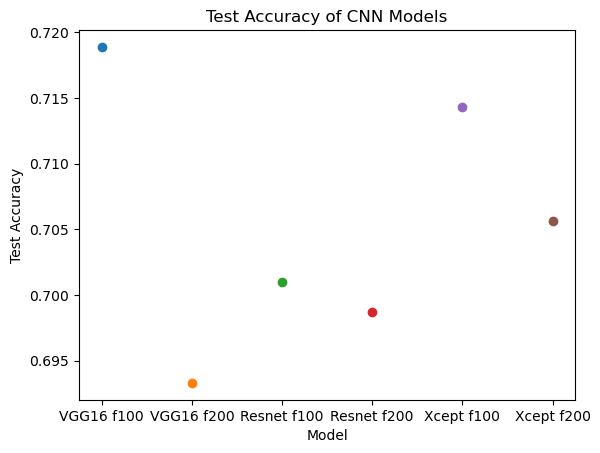

In [64]:
plt.plot("VGG16 f100", 0.7189, marker='o')
plt.plot("VGG16 f200", 0.6933, marker='o')
plt.plot("Resnet f100", 0.701, marker='o')
plt.plot("Resnet f200", 0.6987, marker='o')
plt.plot("Xcept f100", 0.7143, marker='o')
plt.plot("Xcept f200", 0.7056, marker='o')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy of CNN Models')
plt.show()

## Read contours to transform into binary masks

In [55]:
cont = os.listdir(ROOT_DIR + "ExpertsSegmentations/Contours/")[0] # getting file name
print(cont)
img_shape = (1934, 2576, 3) # passing a image shape
# getting mask
mask = utils.contour_to_mask(cont=cont, img_shape=img_shape, abs_path=ROOT_DIR)
print('Mask shape {}'.format(mask.shape))
plt.imshow(mask, cmap='gray') # plotting mask
mask[1000][1250]

RET004OD_disc_exp1.txt
Mask shape (1934, 2576)


1

Error in callback <function flush_figures at 0x00000214AC710DC0> (for post_execute):


KeyboardInterrupt: 

Visual representation:

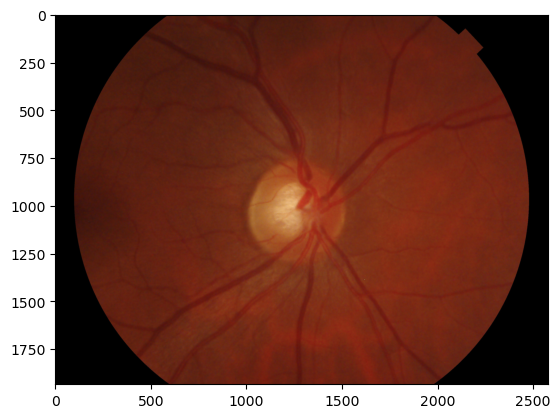

In [ ]:
img_name = os.listdir(ROOT_DIR + "FundusImages")[0] # getting image name
img_from_dir = np.array(Image.open(ROOT_DIR + "FundusImages/" + img_name)) # reading image

cont = os.listdir(ROOT_DIR + "ExpertsSegmentations/Contours/") # getting list of countours from dir.
cup = utils.contour_to_mask(cont=cont[0], img_shape=img_shape, abs_path=ROOT_DIR) # getting cup contour
disc = utils.contour_to_mask(cont=cont[2], img_shape=img_shape, abs_path=ROOT_DIR) # getting disc contour

# applying masks and plotting image
# img_from_dir = utils.apply_mask(image=img_from_dir, mask=cup, color=(0.0, 1.0, 1.0))
# img_from_dir = utils.apply_mask(image=img_from_dir, mask=disc, color=(1.0, 0.0, 0.0))
plt.imshow(img_from_dir) 